In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
## load data
# Single-cell-data 
adata_pre = sc.read_h5ad('../data/frangieh/adata_preprocessed.h5ad')

# LFC data (711 rows x 2000 HVGs)
adata_lfc = sc.read_h5ad('../data/frangieh/log_fold_change_adata_hvg.h5ad')

In [3]:
# calculate basal expression profile from control cells (pertubation = control in each of the 3 conditions)
ctrl_cells = adata_pre[adata_pre.obs['perturbation'] == 'control']

df_ctrl = ctrl_cells.to_df()
df_ctrl['condition'] = ctrl_cells.obs['condition'].values

# mean basal expression per condition (3 rows x ~18.000 genes)
mean_ctrl_by_cond = df_ctrl.groupby('condition').mean()

/tmp/ipykernel_15636/1859275621.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_ctrl_by_cond = df_ctrl.groupby('condition').mean()


In [4]:
# create feature matrix X
# Feature 1: Basale KO-Expression for each row
basal_ko_values = []
for _, row in adata_lfc.obs.iterrows():
    cond = row['condition']
    ko_gene = row['perturbation']
    
    # Wert abfragen (Fallback 0.0 falls nicht in Matrix vorhanden)
    val = mean_ctrl_by_cond.loc[cond, ko_gene] if ko_gene in mean_ctrl_by_cond.columns else 0.0
    basal_ko_values.append(val)

# Feature 2: Condition One-Hot-Encoding
cond_dummies = pd.get_dummies(adata_lfc.obs['condition'], dtype=float)

# Shape: 711 rows x 4 columns
X_features = np.column_stack([basal_ko_values, cond_dummies.values])

feature_names = ['basal_ko_expression'] + list(cond_dummies.columns)

In [5]:
# scale features 
scaler = StandardScaler()
X = scaler.fit_transform(X_features)

# target matrix y: LFCs of 2000 HVGs
y = adata_lfc.X

In [6]:
# save features 
adata_lfc.obsm['X_basal'] = X
adata_lfc.uns['feature_names_basal'] = feature_names


print(f"X (Features) Shape: {X.shape}")  # expected: (711, 4)
print(f"y (Targets)  Shape: {y.shape}")  # expected: (711, 2000)
print(f"used Feature-names: {feature_names}")

X (Features) Shape: (711, 4)
y (Targets)  Shape: (711, 2000)
used Feature-names: ['basal_ko_expression', 'Co-culture', 'Control', 'IFNγ']


In [8]:
# negative control 
np.random.seed(42)
X_random_noise = np.column_stack([cond_dummies.values,np.random.normal(0, 1, size=(adata_lfc.n_obs, 50))])

# positive control 
pca_ideal = PCA(n_components=min(50, adata_lfc.n_obs, adata_lfc.n_vars), random_state=42)
target_pca = pca_ideal.fit_transform(adata_lfc.X)
X_idealized = np.column_stack([cond_dummies.values,target_pca])

adata_lfc.obsm['X_random_noise'] = StandardScaler().fit_transform(X_random_noise)
adata_lfc.obsm['X_idealized'] = StandardScaler().fit_transform(X_idealized)

In [11]:
all_results = []
conditions = ['Control', 'IFNγ', 'Co-culture']

for strategy_name, selected_50 in adata_lfc.uns['subsets'].items():
    # filter for 50 genes and split 40/10 
    adata_50 = adata_lfc[adata_lfc.obs['perturbation'].isin(selected_50)].copy()

    np.random.seed(42)
    test_genes_10 = np.random.choice(selected_50, size=10, replace=False).tolist()
    is_test = adata_50.obs['perturbation'].isin(test_genes_10).values

    X_50 = adata_50.obsm['X_basal']
    X_rand_50 = adata_50.obsm['X_random_noise']
    X_ideal_50 = adata_50.obsm['X_idealized']
    y_50 = adata_50.X

    X_train, X_test = X_50[~is_test], X_50[is_test]
    X_rand_train, X_rand_test = X_rand_50[~is_test], X_rand_50[is_test]
    X_ideal_train, X_ideal_test = X_ideal_50[~is_test], X_ideal_50[is_test]
    y_train, y_test = y_50[~is_test], y_50[is_test]
    obs_test = adata_50.obs[is_test].reset_index(drop=True)

    predictions = {}

    ## Baselines
    # No-Change 
    predictions['No-Change (Zeros)'] = np.zeros_like(y_test)
    
    # Dummy Train Mean
    dummy = DummyRegressor(strategy='mean')
    dummy.fit(X_train, y_train)
    predictions['Dummy Mean'] = dummy.predict(X_test)

    ## fit models
    # Ridge Regression
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, y_train)
    predictions['Ridge (Basal KO)'] = ridge.predict(X_test)

    # Random Forest 
    rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
    predictions['RF (Basal KO)'] = rf.predict(X_test)

    ##Controls
    # Negative Control: Gaussian Noise
    ridge_rand = Ridge(alpha=1.0)
    ridge_rand.fit(X_rand_train, y_train)
    predictions['Negative Control (Noise)'] = ridge_rand.predict(X_rand_test)

    # Positive Control: Idealized Target PCA
    ridge_ideal = Ridge(alpha=1.0)
    ridge_ideal.fit(X_ideal_train, y_train)
    predictions['Positive Control (PCA)'] = ridge_ideal.predict(X_ideal_test)

    # metrices
    for cond in conditions:
        cond_mask = (obs_test['condition'] == cond).values
        y_true_cond = y_test[cond_mask]

        for model_name, y_pred in predictions.items():
            y_pred_cond = y_pred[cond_mask]

            # MSE
            mse = mean_squared_error(y_true_cond, y_pred_cond)

            # Pearson r 
            corrs = []
            for i in range(len(y_true_cond)):
                if np.std(y_pred_cond[i]) > 1e-8 and np.std(y_true_cond[i]) > 1e-8:
                    r, _ = pearsonr(y_true_cond[i], y_pred_cond[i])
                    corrs.append(r)
                else:
                    corrs.append(np.nan)

            all_results.append({
                'Strategy': strategy_name,
                'Condition': cond,
                'Model': model_name,
                'MSE': mse,
                'Pearson_r': np.nanmean(corrs)
            })

df_all_results = pd.DataFrame(all_results)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_all_results)

/tmp/ipykernel_15636/1144960245.py:88: RuntimeWarning: Mean of empty slice
  'Pearson_r': np.nanmean(corrs)
/tmp/ipykernel_15636/1144960245.py:88: RuntimeWarning: Mean of empty slice
  'Pearson_r': np.nanmean(corrs)
/tmp/ipykernel_15636/1144960245.py:88: RuntimeWarning: Mean of empty slice
  'Pearson_r': np.nanmean(corrs)
/tmp/ipykernel_15636/1144960245.py:88: RuntimeWarning: Mean of empty slice
  'Pearson_r': np.nanmean(corrs)
/tmp/ipykernel_15636/1144960245.py:88: RuntimeWarning: Mean of empty slice
  'Pearson_r': np.nanmean(corrs)
/tmp/ipykernel_15636/1144960245.py:88: RuntimeWarning: Mean of empty slice
  'Pearson_r': np.nanmean(corrs)
/tmp/ipykernel_15636/1144960245.py:88: RuntimeWarning: Mean of empty slice
  'Pearson_r': np.nanmean(corrs)
/tmp/ipykernel_15636/1144960245.py:88: RuntimeWarning: Mean of empty slice
  'Pearson_r': np.nanmean(corrs)
/tmp/ipykernel_15636/1144960245.py:88: RuntimeWarning: Mean of empty slice
  'Pearson_r': np.nanmean(corrs)
/tmp/ipykernel_15636/1144960

,Strategy,Condition,Model,MSE,Pearson_r
0,essentiality,Control,No-Change (Zeros),0.007333,NaN
1,essentiality,Control,Dummy Mean,0.002674,0.820945
2,essentiality,Control,Ridge (Basal KO),0.002211,0.845260
3,essentiality,Control,RF (Basal KO),0.002368,0.833863
4,essentiality,Control,Negative Control (Noise),0.004367,0.696509
5,essentiality,Control,Positive Control (PCA),0.001210,0.905670
6,essentiality,IFNγ,No-Change (Zeros),0.007001,NaN
7,essentiality,IFNγ,Dummy Mean,0.003773,0.719343
8,essentiality,IFNγ,Ridge (Basal KO),0.003657,0.731196
9,essentiality,IFNγ,RF (Basal KO),0.002656,0.755832


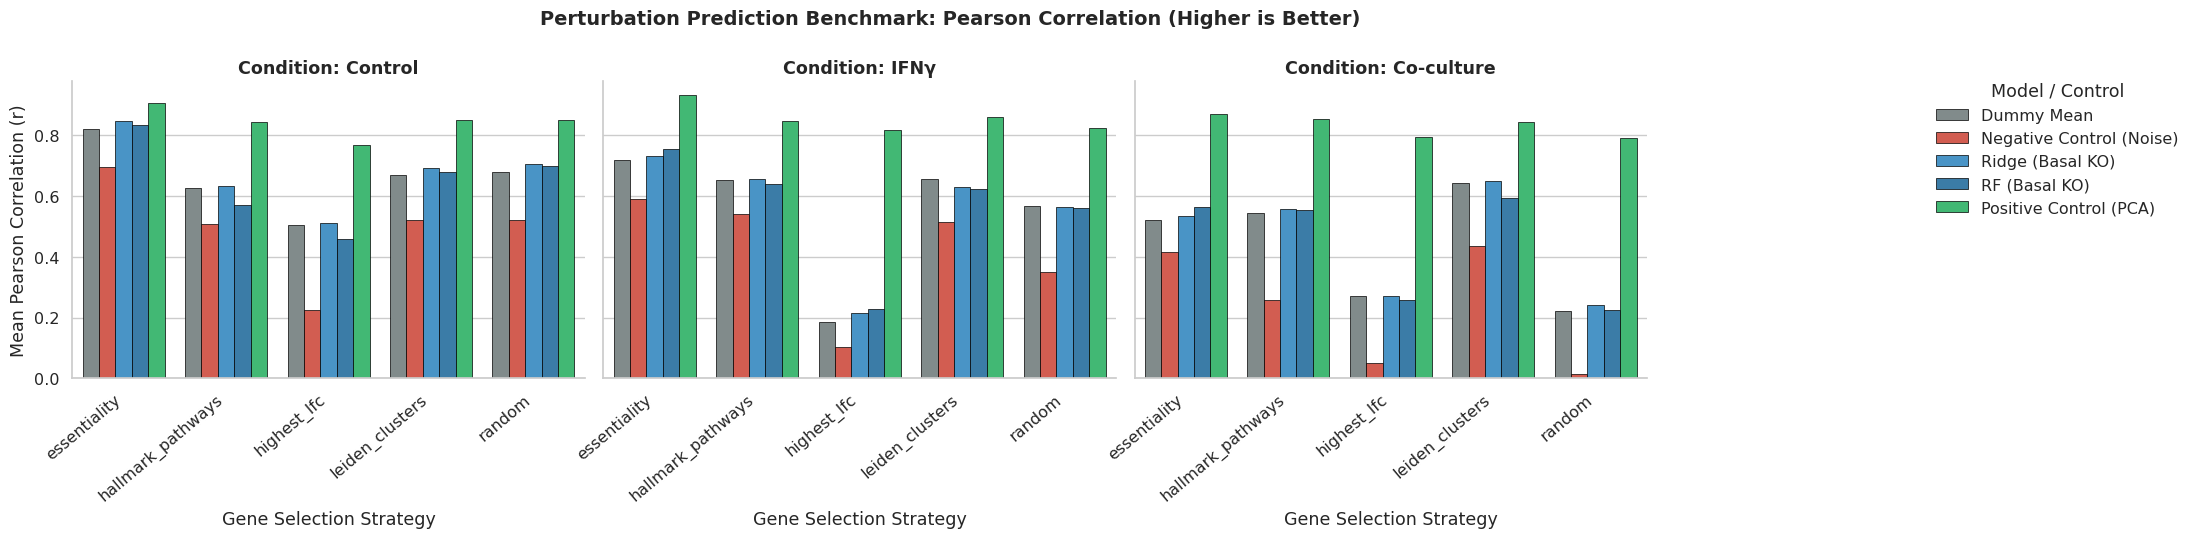

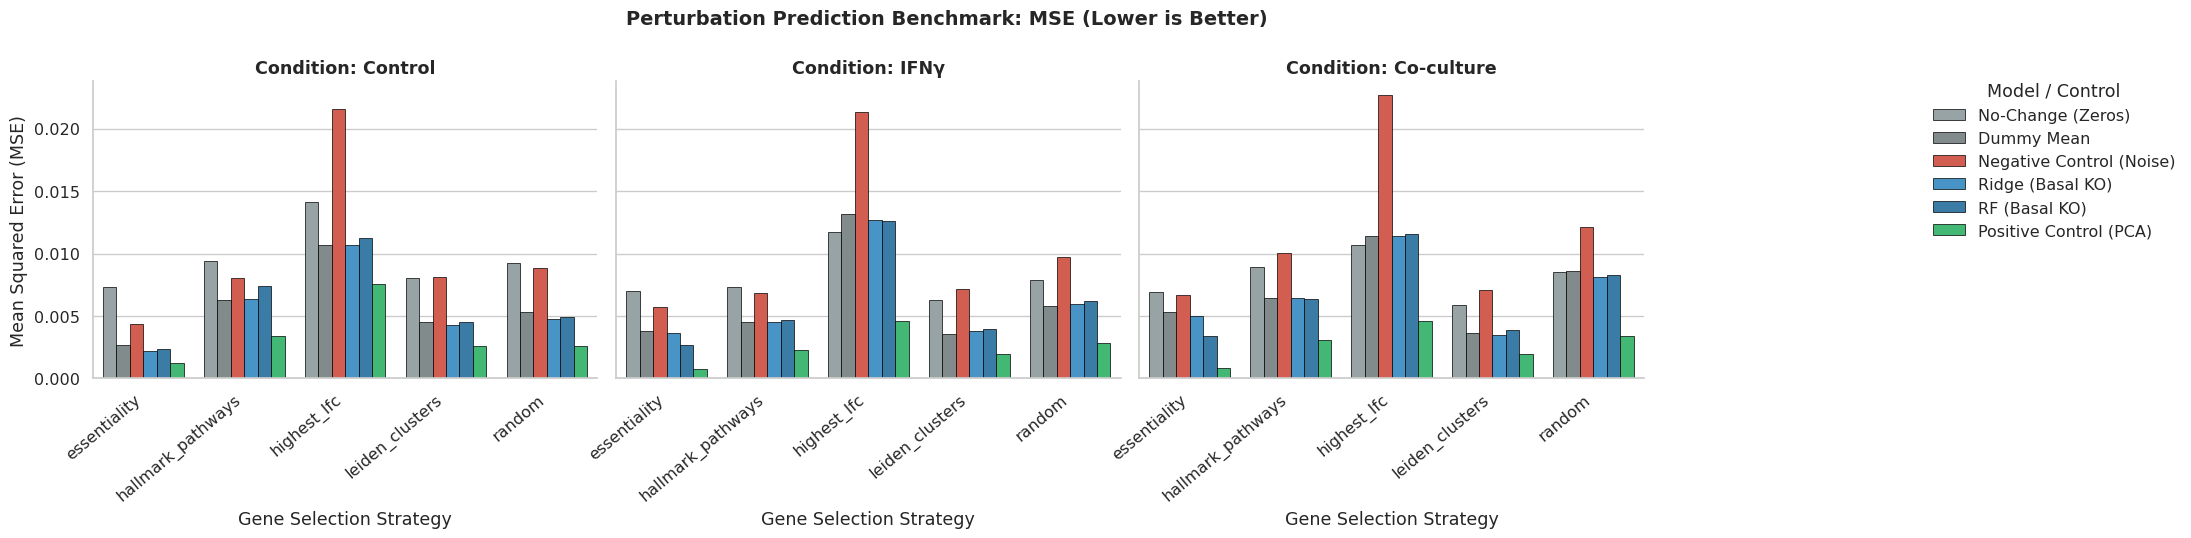

In [14]:
## visualization
model_order = [
    'No-Change (Zeros)',
    'Dummy Mean',
    'Negative Control (Noise)',
    'Ridge (Basal KO)',
    'RF (Basal KO)',
    'Positive Control (PCA)'
]

custom_palette = {
    'No-Change (Zeros)': '#95a5a6',         # gray 
    'Dummy Mean': '#7f8c8d',                # gray 
    'Negative Control (Noise)': '#e74c3c',  # red 
    'Ridge (Basal KO)': '#3498db',          # blue 
    'RF (Basal KO)': '#2980b9',             # blue 
    'Positive Control (PCA)': '#2ecc71'     # green 
}

sns.set_theme(style='whitegrid', font_scale=1.05)


# Pearson Correlation 
g1 = sns.catplot(
    data=df_all_results.dropna(subset=['Pearson_r']),
    x='Strategy',
    y='Pearson_r',
    hue='Model',
    hue_order=[m for m in model_order if m != 'No-Change (Zeros)'],
    col='Condition',
    kind='bar',
    palette=custom_palette,
    height=4.5,
    aspect=1.25,
    edgecolor='black',
    linewidth=0.5
)

g1.set_axis_labels('Gene Selection Strategy', 'Mean Pearson Correlation (r)')
g1.set_titles(col_template='Condition: {col_name}', weight='bold')
g1.set_xticklabels(rotation=40, ha='right')
g1.figure.subplots_adjust(top=0.82)
g1.figure.suptitle('Perturbation Prediction Benchmark: Pearson Correlation (Higher is Better)', fontsize=14, weight='bold')

sns.move_legend(g1, "upper left", bbox_to_anchor=(1.0, 0.85), title='Model / Control')
plt.show()


# MSE

g2 = sns.catplot(
    data=df_all_results,
    x='Strategy',
    y='MSE',
    hue='Model',
    hue_order=model_order,
    col='Condition',
    kind='bar',
    palette=custom_palette,
    height=4.5,
    aspect=1.25,
    edgecolor='black',
    linewidth=0.5
)

g2.set_axis_labels('Gene Selection Strategy', 'Mean Squared Error (MSE)')
g2.set_titles(col_template='Condition: {col_name}', weight='bold')
g2.set_xticklabels(rotation=40, ha='right')
g2.figure.subplots_adjust(top=0.82)
g2.figure.suptitle('Perturbation Prediction Benchmark: MSE (Lower is Better)', fontsize=14, weight='bold')

sns.move_legend(g2, "upper left", bbox_to_anchor=(1.0, 0.85), title='Model / Control')
plt.show()